# Практика. Подтверждающий анализ

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

>#### Задание 1
Прочитайте файл `hospital`.

In [2]:
df = pd.read_csv('data/hospital.csv')
df

,patient_id,age,gender,doctor_id,specialization,primary_symptoms_score,prescribed_treatment,visited_again_30days,satisfaction_score,invoice_amount
0,1,69,NaN,11,невролог,5,лекарства,Да,3.0,1345.07
1,2,32,М,6,кардиолог,9,лекарства,Нет,6.0,2571.06
2,3,78,Ж,18,хирург,3,наблюдение,Нет,NaN,1991.05
3,4,38,Ж,10,невролог,7,процедуры,Да,10.0,1198.26
4,5,41,М,4,терапевт,1,процедуры,Нет,9.0,1402.55
...,...,...,...,...,...,...,...,...,...,...
995,996,21,М,15,хирург,1,направление к другому специалисту,Нет,6.0,1487.52
996,997,43,М,9,кардиолог,1,наблюдение,Нет,7.0,1452.38
997,998,75,NaN,19,хирург,1,процедуры,Нет,3.0,1314.86
998,999,46,М,9,кардиолог,1,лекарства,Нет,0.0,1190.95


#### Контекст

Сеть частных медицинских клиник «Здоровье+» хочет проанализировать эффективность повторных визитов пациентов после первичного приёма. Данные собраны за последние полгода. Врачи клиники получают бонусы в зависимости от того, сколько пациентов возвращаются к ним на повторный приём в течение 30 дней после первого визита. Руководство подозревает, что некоторые врачи «накручивают» показатель повторных визитов, назначая пациентам ненужные повторные процедуры. Отдел аналитики должен проверить эту гипотезу.

#### Признаки датасета

- patient_id — уникальный идентификатор пациента

- age — возраст пациента на момент первого визита (полных лет)

- gender — пол пациента (М / Ж / указан не был)

- doctor_id — уникальный идентификатор врача

- specialization — специализация врача (терапевт / кардиолог / невролог / хирург)

- primary_symptoms_score — балл тяжести симптомов при первичном обращении (от 1 — лёгкие до 10 — критические, на основе опросника пациента)

- prescribed_treatment — назначенное лечение (лекарства / процедуры / наблюдение / направление к другому специалисту)

- visited_again_30days — вернулся ли пациент на повторный приём в течение 30 дней после первого визита (Да / Нет)

- satisfaction_score — оценка удовлетворённости пациента по результатам первого визита (от 0 — ужасно до 10 — идеально)

- invoice_amount — сумма чека за первый визит (в рублях)


#### Причины пропусков

- satisfaction_score (числовой, диапазон 0–10): некоторые пациенты отказались заполнять анкету удовлетворённости после первого визита, сославшись на нехватку времени. Пропуски составили около 12 % записей.

- gender (категориальный): при регистрации в электронной очереди пациенты могли не указывать пол (MNAR — некоторые пациенты сознательно пропускали это поле, опасаясь дискриминации по полу при приёме к некоторым специалистам). Общий уровень пропусков — 15 %.

#### Бизнес-проблема


Руководство клиники хочет выяснить: 1) завышают ли врачи  показатели возврата пациентов, и если да — какие именно врачи и какой специализации этим грешат; 2) нет ли среди врачей  тех, кто необосновано завышает стоимость оказываемых им услуг. На основе результатов EDA+CDA необходимо предложить меры: провести внутреннюю проверку в отношении конкретных врачей.


>#### Задание 2
>Проведите первичный осмотр данных. Напишите резюме.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              1000 non-null   int64  
 1   age                     1000 non-null   int64  
 2   gender                  813 non-null    object 
 3   doctor_id               1000 non-null   int64  
 4   specialization          1000 non-null   object 
 5   primary_symptoms_score  1000 non-null   int64  
 6   prescribed_treatment    1000 non-null   object 
 7   visited_again_30days    1000 non-null   object 
 8   satisfaction_score      882 non-null    float64
 9   invoice_amount          1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


Пропуски по полу и по удовлетворенности. По удовлетворенности — MCAR, по полу — MNAR. Пропусков много. Удалять нельзя.

In [4]:
df.describe()

,patient_id,age,doctor_id,primary_symptoms_score,satisfaction_score,invoice_amount
count,1000.000000,1000.0000,1000.000000,1000.000000,882.000000,1000.000000
mean,500.500000,50.6760,10.340000,5.423000,5.026077,1838.875700
std,288.819436,19.7803,5.700956,2.817092,3.101096,656.537785
min,1.000000,18.0000,1.000000,1.000000,0.000000,614.080000
25%,250.750000,34.0000,5.000000,3.000000,2.000000,1378.560000
50%,500.500000,50.0000,10.000000,5.000000,5.000000,1673.040000
75%,750.250000,68.0000,15.000000,8.000000,8.000000,2166.352500
max,1000.000000,84.0000,20.000000,10.000000,10.000000,5185.550000


In [5]:
df.describe(include='object')

,gender,specialization,prescribed_treatment,visited_again_30days
count,813,1000,1000,1000
unique,2,4,4,2
top,Ж,хирург,направление к другому специалисту,Нет
freq,408,335,264,584


Очевидных выбросов нет.

Посмотрим распределения числовых признаков:

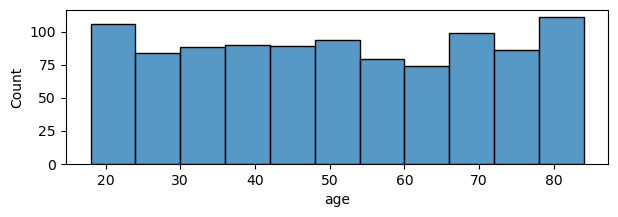

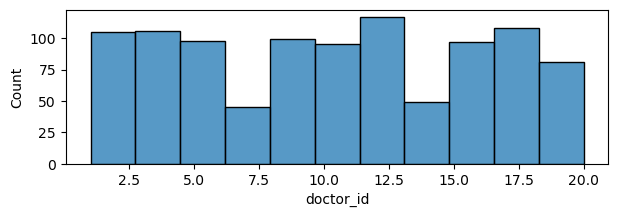

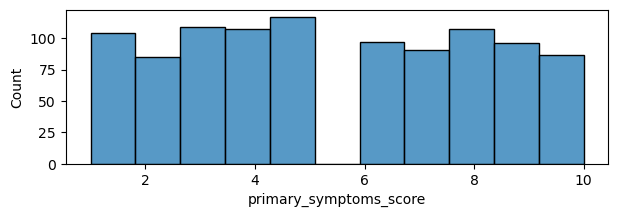

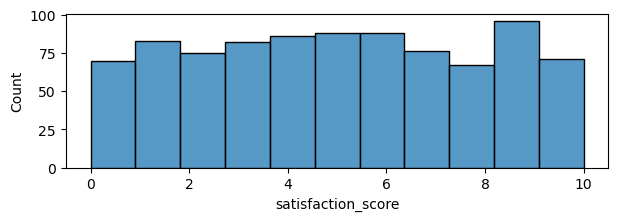

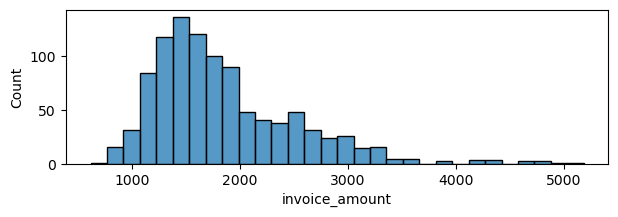

In [6]:
num_col_list = ['age', 'doctor_id', 'primary_symptoms_score', 'satisfaction_score', 'invoice_amount']

for col in num_col_list:
    plt.figure(figsize=(7, 2))
    sns.histplot(data=df, x=col)
    plt.show()

А теперь — распределения категориальных:

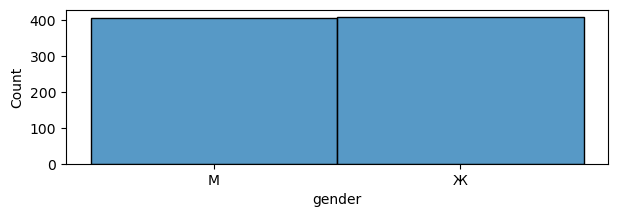

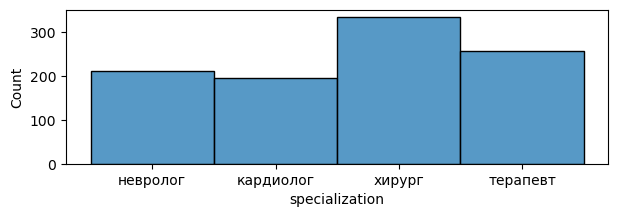

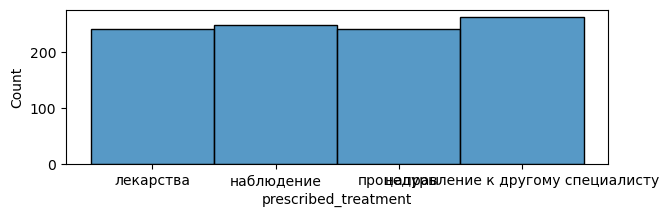

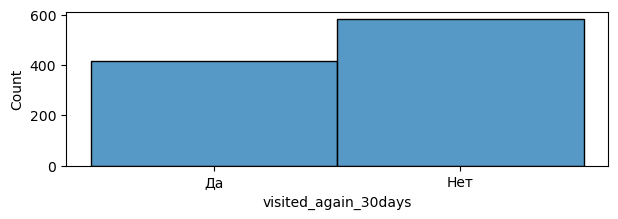

In [7]:
cat_col_list = ['gender', 'specialization', 'prescribed_treatment', 'visited_again_30days']

for col in cat_col_list:
    plt.figure(figsize=(7, 2))
    sns.histplot(data=df, x=col)
    plt.show()

Очевидных аномалий не видим.

#### Резюме

Пропуски в признаках `'gender'` (категория пропуска MCAR) и `'satisfaction_score'` (категория MNAR). Пропусков много, удалять нельзя. Очевидных выбросов нет. Очевидных аномалий в распределениях нет.

>#### Задание 3
>Проведите обработку пропусков. Обоснуйте выбор того или иного способы обработки (удалить, заменить на среднее, заменить на среднее по группе и т. д.).

Начинаем с `'gender'`. Это категориальный признак. Смотрим, есть ли ярко выраженная мода в какой либо категории категориальных признаков:

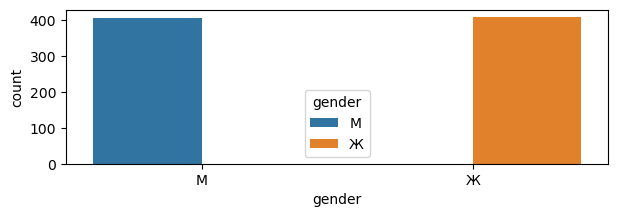

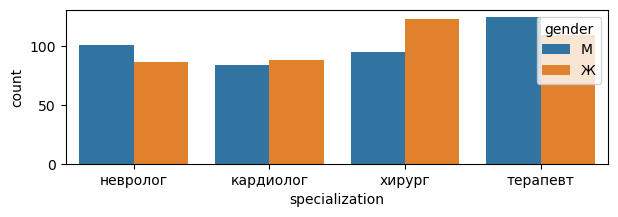

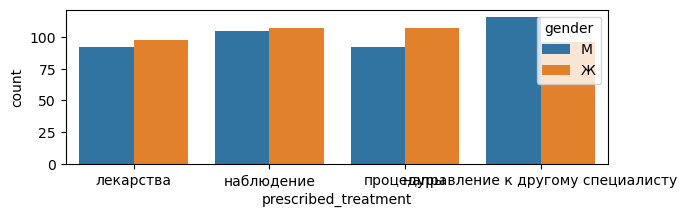

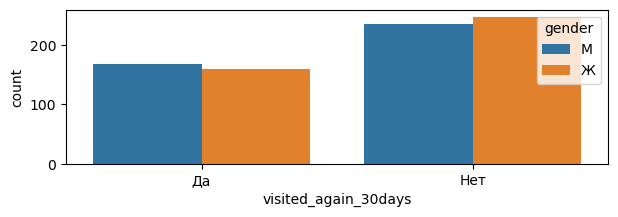

In [8]:
for col in cat_col_list:
    plt.figure(figsize=(7, 2))
    sns.countplot(data=df, x=col, hue='gender')
    plt.show()

Ярко выраженных мод (>75%) нет.

Некоторые числовые признаки являются по сути категориальными. Смотрим на моды в таких признаках:

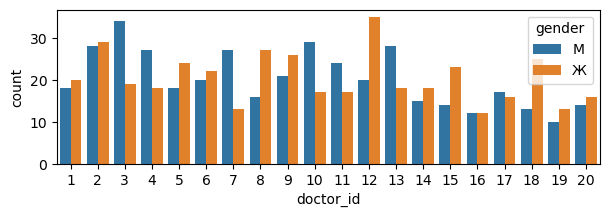

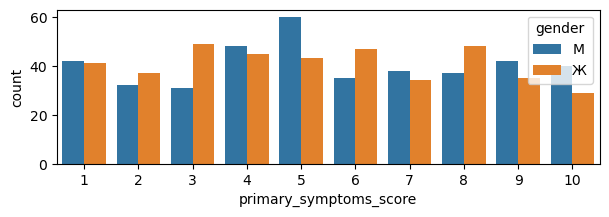

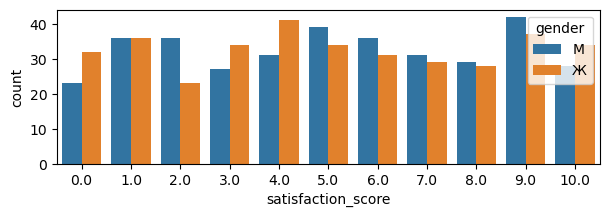

In [9]:
num_cat_col_list = ['doctor_id', 'primary_symptoms_score', 'satisfaction_score']

for col in num_cat_col_list:
    plt.figure(figsize=(7, 2))
    sns.countplot(data=df, x=col, hue='gender')
    plt.show()

Тоже ничего не видим. Ярко выраженной моды нет ни в одной из категорий, поэтому мы заменяем пропуски на третье значение `'Не указано'`:

In [10]:
df['gender'] = df['gender'].fillna('Не указано')

Переходим к пропускам в признаке 'satisfaction_score'. Это числовой признак. Поэтому посмотрим на него по-другому, с позиций метода `boxplot`. Смотрим, как распределена оценка удовлетвороенности относительно разных категорий:

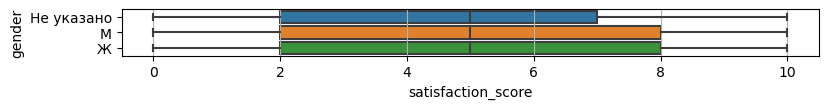

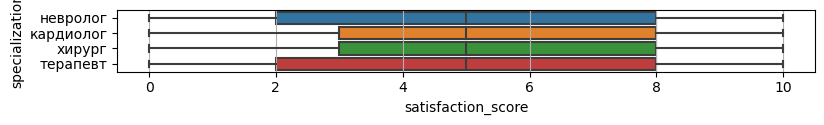

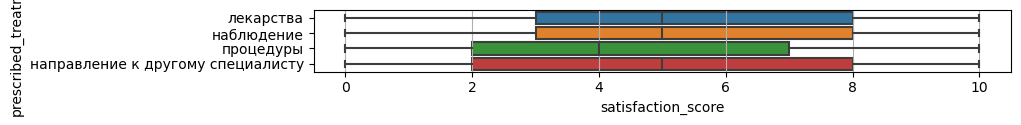

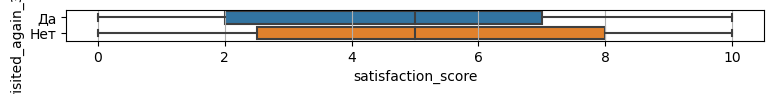

In [11]:
len_list = []
for col in cat_col_list:
    len_list.append(df[col].nunique())

for i in range(len(cat_col_list)):
    plt.figure(figsize=(9, 0.2*len_list[i]))
    plt.grid()
    sns.boxplot(data=df, x='satisfaction_score', y=cat_col_list[i])
    plt.show()

Ничего интересного не видим. Медиана — почти всегда 5, иногда (точнее 1 раз) 4. 

Вспоминаем, что у нас есть признаки, которые числовые, но по сути — категоральные. И точно так же визуализируем распределение удовлетвороенности относительно них:

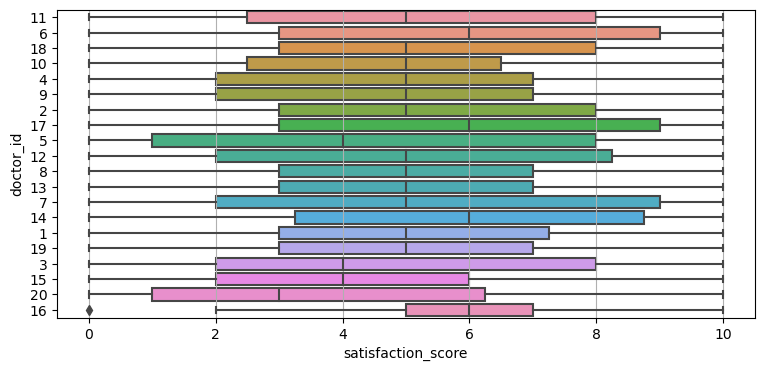

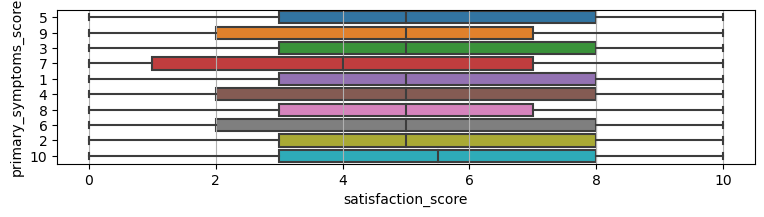

In [12]:
df_copy = df.copy()

num_cat_col_list = ['doctor_id', 'primary_symptoms_score']

for col in num_cat_col_list:
    df_copy[col] = df_copy[col].astype(str)

len_list = []
for col in num_cat_col_list:
    len_list.append(df_copy[col].nunique())

for i in range(len(num_cat_col_list)):
    plt.figure(figsize=(9, 0.2*len_list[i]))
    plt.grid()
    sns.boxplot(data=df_copy, x='satisfaction_score', y=num_cat_col_list[i])
    plt.show()

Но вывод другой: да, медиана почти всегда 5, иногда 4 или 6 и один раз 5.5, но один раз — это 3 (у доктора с  номером 20). Вывод — заменять на медианы по категориям признака doctor_id. Так будет честнее.

In [13]:
def sat_score_imputation(row):
    if row['satisfaction_score'] != row['satisfaction_score']:
        d = df.loc[df['doctor_id'] == row['doctor_id']]
        return d['satisfaction_score'].median()
    else:
        return row['satisfaction_score']
    
df['satisfaction_score'] = df.apply(sat_score_imputation, axis=1)

Заменили. Теперь в данных нет пропусков:

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              1000 non-null   int64  
 1   age                     1000 non-null   int64  
 2   gender                  1000 non-null   object 
 3   doctor_id               1000 non-null   int64  
 4   specialization          1000 non-null   object 
 5   primary_symptoms_score  1000 non-null   int64  
 6   prescribed_treatment    1000 non-null   object 
 7   visited_again_30days    1000 non-null   object 
 8   satisfaction_score      1000 non-null   float64
 9   invoice_amount          1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


И, исключительно из эстетических соображений, поменяем тип признака `'satisfaction_score'` на int:

In [15]:
df['satisfaction_score'] = df['satisfaction_score'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              1000 non-null   int64  
 1   age                     1000 non-null   int64  
 2   gender                  1000 non-null   object 
 3   doctor_id               1000 non-null   int64  
 4   specialization          1000 non-null   object 
 5   primary_symptoms_score  1000 non-null   int64  
 6   prescribed_treatment    1000 non-null   object 
 7   visited_again_30days    1000 non-null   object 
 8   satisfaction_score      1000 non-null   int32  
 9   invoice_amount          1000 non-null   float64
dtypes: float64(1), int32(1), int64(4), object(4)
memory usage: 74.3+ KB


Теперь наши данные в идеальном состоянии. Ну, почти в идеальном. Нам еще надо обработать выбросы.

>#### Задание 4
>Проведите обработку выбросов. Обоснуйте выбор того или иного способы обработки (удалить, не удалять, заменить и т. д.).

В нечисловых признаках выбросы невозможны по определению.

Собственно числовых признаков — всего два: возраст и стоимость. Посмотрим еще раз на из распределения:

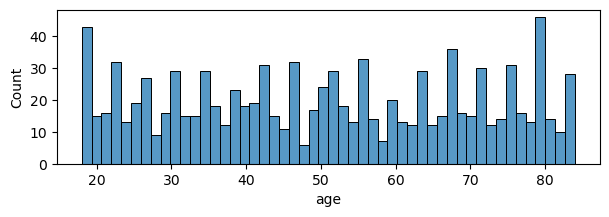

In [16]:
plt.figure(figsize=(7, 2))
sns.histplot(data=df, x='age', bins= 50)
plt.show()

Выбросов по возрасту нет. Смотрим на цену.

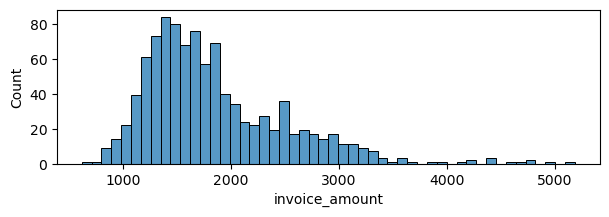

In [17]:
plt.figure(figsize=(7, 2))
sns.histplot(data=df, x='invoice_amount', bins= 50)
plt.show()

Есть правый хвост, начиная примерно с 3500. Но разумно ли обрабатывать эти значения (удалять, заменять на средние)? Ответ — нет. Потому что, во-первых, это могут быть цены, связанные с особо тяжелыми случаями, а во-вторых в рамках заявленной бизнес-проблемы нам помимо манипуляций с возвратами необходимо проанализировать манипуляции с ценами, а они могут быть связаны именно с аномальными значениями цен.

>#### Задание 5
Проанализируйте данные с точки зрения заявленной бизнес-проблемы и дайте управленческие рекомендации.

Анализируем манипуляции с возвратами. Берем всех докторов и смотрим на соотношения по возвратам: 

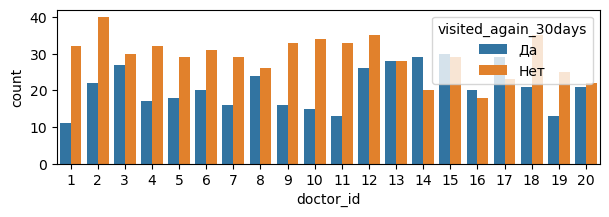

In [18]:
plt.figure(figsize=(7, 2))
sns.countplot(data=df, x='doctor_id', hue='visited_again_30days')
plt.show()

На первый взгляд — среди подозреваемых доктора 3, 8, 12, 13, 14, и 17. 

Но не будем спешить с выводами. Возможно, возвраты связаны со специализацией врачей или с другими факторами. Прогоним соотношения счетчики возвратов через другие признаки.

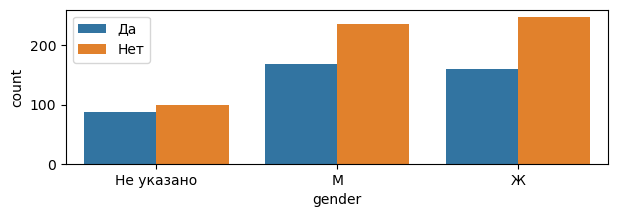

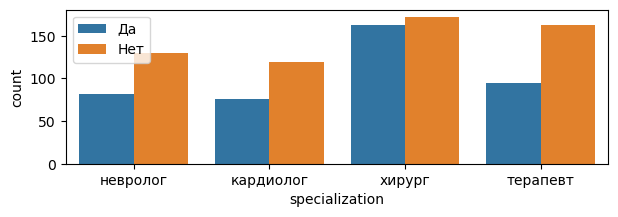

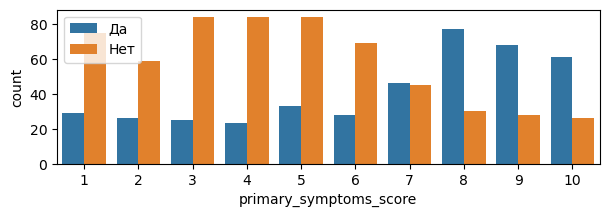

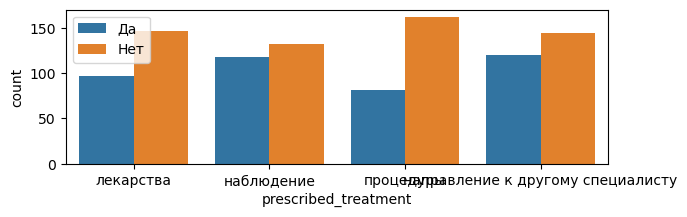

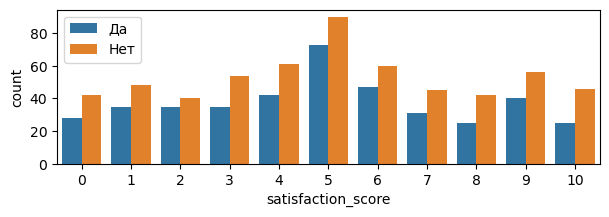

In [19]:
col_list = ['gender', 'specialization', 'primary_symptoms_score', 'prescribed_treatment',
             'satisfaction_score']

for col in col_list:
    plt.figure(figsize=(7, 2))
    sns.countplot(data=df, x=col, hue='visited_again_30days')
    plt.legend(loc=2)
    plt.show()

И вот, что мы видим: если у пациента тяжелый первичный диагноз, то доля возвратов среди таких пациентов необыкновенно высока. Это не случайно. Возвраты зависят от тяжести первичного диагноза. Поэтому, просто смотреть на долю возвратов по каждому доктору — это плохая идея. Если у него много тяжелых случаев, то у него будет и много возвратов.

Но вот если наоборот — тяжелых случаев мало, но при этом возвратов много — то это повод для подозрения в манипуляции.

Заводим два маркера: является ли диагноз тяжелым и возвращался ли пациент.

In [20]:
def is_hard(row):
    if row['primary_symptoms_score']>=7:
        return 1
    else:
        return 0

def is_return(row):
    if row['visited_again_30days']== 'Да':
        return 1
    else:
        return 0
    
df['is_hard'] = df.apply(is_hard, axis=1)
df['is_return'] = df.apply(is_return, axis=1)
df

,patient_id,age,gender,doctor_id,specialization,primary_symptoms_score,prescribed_treatment,visited_again_30days,satisfaction_score,invoice_amount,is_hard,is_return
0,1,69,Не указано,11,невролог,5,лекарства,Да,3,1345.07,0,1
1,2,32,М,6,кардиолог,9,лекарства,Нет,6,2571.06,1,0
2,3,78,Ж,18,хирург,3,наблюдение,Нет,5,1991.05,0,0
3,4,38,Ж,10,невролог,7,процедуры,Да,10,1198.26,1,1
4,5,41,М,4,терапевт,1,процедуры,Нет,9,1402.55,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,21,М,15,хирург,1,направление к другому специалисту,Нет,6,1487.52,0,0
996,997,43,М,9,кардиолог,1,наблюдение,Нет,7,1452.38,0,0
997,998,75,Не указано,19,хирург,1,процедуры,Нет,3,1314.86,0,0
998,999,46,М,9,кардиолог,1,лекарства,Нет,0,1190.95,0,0


И после этого проводим группировку по докторам:

In [21]:
result = df.groupby('doctor_id').agg(
    is_hard = ('is_hard', 'sum'),
    is_return = ('is_return', 'sum'),
   )
result

,is_hard,is_return
doctor_id,,
1,13,11
2,26,22
3,21,27
4,15,17
5,20,18
6,17,20
7,16,16
8,22,24
9,18,16


Добавляем дополнительный признак — отношение числа возвратов к числу тяжелых диагнозов — и упорядочиваем результат по убыванию этого отношения:

In [22]:
result['ratio'] = result['is_return']/result['is_hard']
result_sorted = result.sort_values(by='ratio', ascending=False)
result_sorted = result_sorted.reset_index()
result_sorted['doctor_id'] = result_sorted['doctor_id'].astype(str)
result_sorted

,doctor_id,is_hard,is_return,ratio
0,16,13,20,1.538462
1,3,21,27,1.285714
2,13,22,28,1.272727
3,17,24,29,1.208333
4,14,24,29,1.208333
5,15,25,30,1.200000
6,19,11,13,1.181818
7,6,17,20,1.176471
8,4,15,17,1.133333
9,8,22,24,1.090909


Мы получили рейтинг подозрений на манипуляции с возвратами. И если вы хотите проводить проверки, то проводите их в соответствии с этим рейтингом сверху вниз. Причем обратите внимание, кто лидер рейтинга: доктор 16, которого среди первоначального списка подозреваемых вообще не было! Там были 3, 8, 12, 13, 14, и 17. А 16 — не было!

Вот визуализация рейтинга подозрений:

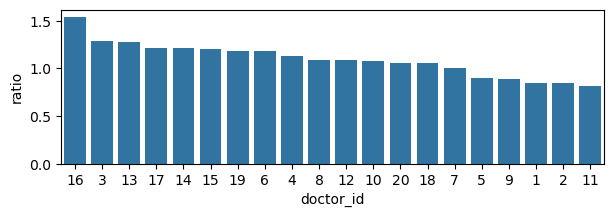

In [23]:
plt.figure(figsize=(7, 2))
sns.barplot(data=result_sorted, x='doctor_id', y='ratio', color='C0')
plt.show()

Отметим, что подозрение — это еще не обвинение. Возможно, врач 16 настолько хорош, что пациенты возвращаются к нему просто из чувства симпатии. Или что-то еще. Мы всего лишь указали порядок, в котором следует проводить аудит.

Далее перейдем к анализу цен. Цена — это числовой признак, для визуального анализа применяем серию ящиков с усами по категориальным признакам:

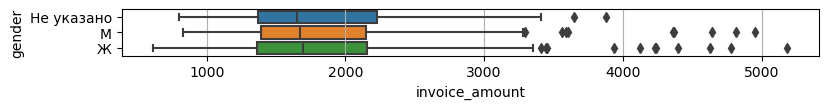

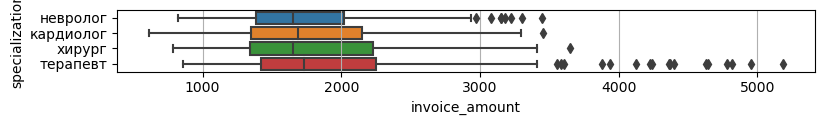

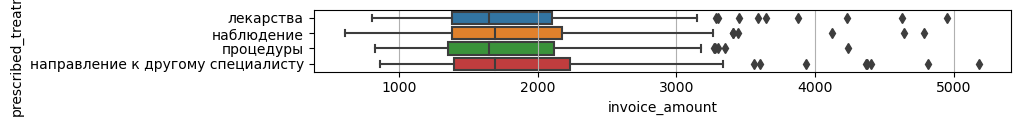

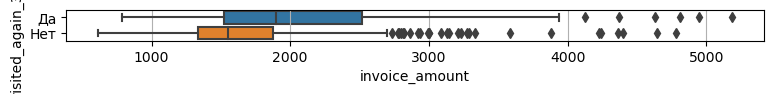

In [24]:
len_list = []
for col in cat_col_list:
    len_list.append(df[col].nunique())

for i in range(len(cat_col_list)):
    plt.figure(figsize=(9, 0.2*len_list[i]))
    plt.grid()
    sns.boxplot(data=df, x='invoice_amount', y=cat_col_list[i])
    plt.show()

Видим очевидный сдвиг по повторным посещениям. Это вполне естественно: чем больше визитов, тем больше заплатишь. Это пока не дает никаких дополнительных сведений.

Вспоминаем, что, помимо собственно категориальных признаков, у нас есть еще несколько числовых признаков, которые по сути являются категориальными. И прогоним визуализацию цен через категории таких признаков:

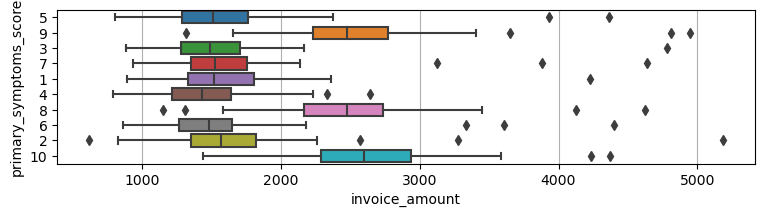

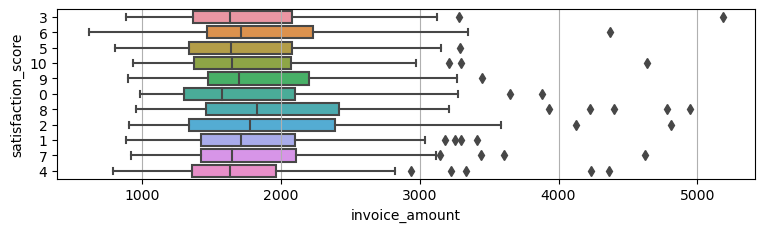

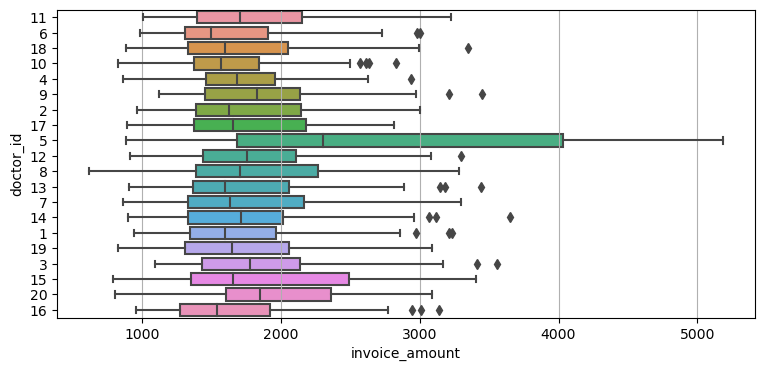

In [25]:
df_copy = df.copy()

num_cat_col_list = ['primary_symptoms_score', 'satisfaction_score', 'doctor_id']

for col in num_cat_col_list:
    df_copy[col] = df_copy[col].astype(str)

len_list = []
for col in num_cat_col_list:
    len_list.append(df_copy[col].nunique())

for i in range(len(num_cat_col_list)):
    plt.figure(figsize=(9, 0.2*len_list[i]))
    plt.grid()
    sns.boxplot(data=df_copy, x='invoice_amount', y=num_cat_col_list[i])
    plt.show()

Видим явное смещение цен у пациентов  с тяжелыми диагнозами. Это естественно, ничего странного. 

А вот смещение доктора номер 5 — вызывает удивление. С чего бы это? В рейтинге манипуляторов с возвратами доктор 5 занимает скромное 15-е место. Возвратов у него немного. Так почему так дорого обходятся его услуги?

Смещение столь очевидно, что можно даже не обращаться к статистическим критериям. Но для убедительности мы проведем тест  Манна-Уитни:

In [26]:
mask = df['doctor_id'] == 5

sample1 = df.loc[mask]['invoice_amount']
sample2 = df.loc[~mask]['invoice_amount']
stat, p = mannwhitneyu(sample1, sample2, alternative='two-sided')
p

4.85448152349678e-06

Значение p-value меньше уровня значимости 0.05. Сдвиг достоверен.

Еще раз отметим, что мы не вынесли приговор доктору 5 (возможно, он применяет дорогостоящие препараты или сложные методики лечения). Мы лишь указали на некоторое несоответствие. Это и есть наша рекомендация руководству клиники: проведите проверку доктора 16 по поводу его возвратов и доктора 5 по поводу его цен.